# Простые методы предсказания ВР

## Содержание



|раздел | [Nixtla](https://nixtlaverse.nixtla.io/statsforecast/) / [GitHub](https://github.com/Nixtla/statsforecast/blob/main/nbs/docs/)| [FPPPY](https://otexts.com/fpppy/)|
|-------|-----------------------|------|
|QuickStart| [statsforecast](https://nixtlaverse.nixtla.io/statsforecast/docs/getting-started/getting_started_short.html)/[end2end tour](https://nixtlaverse.nixtla.io/statsforecast/docs/getting-started/getting_started_complete.html#train-multiple-models-for-many-series)/ [GitHub](https://github.com/Nixtla/statsforecast/blob/main/nbs/docs/getting-started/getting_Started_short.ipynb) [GitHub2](https://github.com/Nixtla/statsforecast/blob/main/nbs/docs/getting-started/getting_Started_complete.ipynb)| [Chp1](https://otexts.com/fpppy/nbs/01-intro.html), [5.1](https://otexts.com/fpppy/nbs/05-toolbox.html)|
|Naive |    [models_intro](https://nixtlaverse.nixtla.io/statsforecast/src/core/models_intro.html)   | [5.2](https://otexts.com/fpppy/nbs/05-toolbox.html#sec-simple-methods)|
|ExpSmooth | [automatic_forecasting](https://nixtlaverse.nixtla.io/statsforecast/docs/how-to-guides/automatic_forecasting.html),/[ETS at scale](https://nixtlaverse.nixtla.io/statsforecast/docs/experiments/ets_ray_m5.html) [GitHub](https://github.com/Nixtla/statsforecast/blob/main/nbs/docs/models/AutoETS.ipynb)| [Chapter 8](https://otexts.com/fpppy/nbs/08-exponential-smoothing.html)|
|STL | [MSTL](https://nixtlaverse.nixtla.io/statsforecast/docs/tutorials/multipleseasonalities.html) [GitHub](https://github.com/Nixtla/statsforecast/blob/main/nbs/docs/tutorials/MultipleSeasonalities.ipynb)  |[3.6](https://otexts.com/fpppy/nbs/03-decomposition.html#sec-stl), [5.7](https://otexts.com/fpppy/nbs/05-toolbox.html#sec-forecasting-decomposition), [12.1](https://otexts.com/fpppy/nbs/12-advanced.html#sec-complexseasonality)|
|Prophet|    [forecast-function-using-prophet](https://nixtlaverse.nixtla.io/statsforecast/docs/experiments/prophet_spark_m5.html#forecast-function-using-prophet) [GitHub](https://github.com/Nixtla/statsforecast/tree/main/nbs/docs/experiments) | [12.2](https://otexts.com/fpppy/nbs/12-advanced.html#sec-prophet) |

* [Effortless Accuracy Unlocking the Power of Baseline Forecasts](https://www.nixtla.io/blog/baseline-forecasts)
* [Out-of-Sample Time Series Forecasting (TSF) via Auto models](https://readmedium.com/out-of-sample-time-series-forecasting-tsf-via-nixtlas-statsforecast-autoarima-autoets-0e163a22d9cb)
* [Automatic Time Series Forecasting](https://nixtlaverse.nixtla.io/statsforecast/docs/how-to-guides/automatic_forecasting.html) / [GitHub](https://github.com/Nixtla/statsforecast/blob/main/nbs/docs/how-to-guides/Automatic_Forecasting.ipynb)
* [Auto models selection statforecast](https://www.nixtla.io/blog/statsforecast-automatic-model-selection)
* [arima_prophet_adapter](https://github.com/Nixtla/statsforecast/blob/main/experiments/arima_prophet_adapter/README.md)
* [StatForecast in AutoGluno using](https://readmedium.com/autogluon-timeseries-every-time-series-forecasting-model-in-one-library-29a3bf6879db)

## Библиотеки экосистемы анализа временных рядов Nixtla 

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [6]:
from statsforecast import StatsForecast
from statsforecast.models import *

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, rmse, smape, mase

In [7]:
from TSC_Nixtla_dump import *
plt_style_GOST()

### Загрузка данных

Загрузим данные

In [8]:
df_ = pd.read_csv(
    "OPDS_DE_EDA.csv",
    parse_dates=["time"],
    index_col="time"
)
df_.head(1)

,Consumption,Wind,Solar,temperature,radiation_direct_horizontal,hour,month,day_of_week,Consumption_detrended,season,day_of_week_str,daylight_duration,week,is_holiday,Consumption_resid,Wind_resid,Solar_resid,temperature_resid,radiation_direct_horizontal_resid
time,,,,,,,,,,,,,,,,,,,
2015-01-01,41.151,8.852,0.071,-0.981,0.0,0,1,3,-7.29271,Winter,Thu,7.921998,1,True,0.136794,0.610749,0.382488,-4.475639,-7.584582


Выберем ВР для дальнейшего анализа

In [9]:
ts = ['Consumption','Wind',	'Solar']
exog_cols = ['temperature','radiation_direct_horizontal']

Для простоты освоения инструментов возьмам данные только с самым длинным периодом. То есть усредрим все более быстрые колебания. Данные будем рассматривать с шагом в неделю. У нас остается 1 сезонная компонента со значением сезона - 53 недели (1 год)

In [10]:
y = df_.resample('W').agg({
    'Consumption': 'sum',
    'Wind': 'sum',
    'Solar': 'sum',
    'temperature': 'mean',
    'radiation_direct_horizontal': 'mean'
})

y = y.iloc[1:-2]

### Приведение данных к long формату

#### Преобразуем временной ряд к стандартному для `Nixtla` виду `panel`. 

Такой формат данных это по сути т.н. long данные - когда все ВР составлены в столбец. И каждый ВР выбирается по уникальному идентификатору.

Для этого создадим соответствующие столбцы:
* `ds` - временные метки.
* `unique_id` - название временного ряда. Это будет полезно при использовании многопеременных или иерархических временных рядов.
* `y` - целевая переменная ВР. В случае ногопеременных или иерархических временных рядов метки будут разделяться по их `unique_id`.

Такой формат [с укажанием id каждой записи](https://nixtlaverse.nixtla.io/neuralforecast/examples/data_format.html) представления временных рядов известен как [<tt>long format</tt>](https://www.theanalysisfactor.com/wide-and-long-data/).

In [11]:
ts = ['Consumption', 'Wind', 'Solar']
base_cols = ['unique_id', 'ds', 'y']

date_index = y.index
panel_list = [pd.DataFrame({'ds':date_index , 'y': y[t].values, 'unique_id': t}) for t in ts]
panel_df = pd.concat(panel_list, ignore_index=True)
panel_df = panel_df[base_cols] #порядок колонок
panel_df.sample(5)

,unique_id,ds,y
360,Wind,2016-12-18,868.588
752,Solar,2019-07-07,1415.275
669,Solar,2017-12-03,128.246
480,Wind,2019-04-07,1583.140
390,Wind,2017-07-16,1124.569


#### ВР
Проверим, что у нас действительно все датасеты  

In [12]:
panel_df['unique_id'].unique()

array(['Consumption', 'Wind', 'Solar'], dtype=object)

#### Получим частоту для дальнейшей работы

In [13]:
FREQ = y.index.freq
FREQ

<Week: weekday=6>

#### Проверим значенипе сезонности при помощи утилиты `find_season_length`

In [14]:
from coreforecast.seasonal import find_season_length

In [15]:
SEASON = find_season_length(y['Consumption'].values, max_season_length = 55)
SEASON

52

#### экзогенные переменные

Также попробуем добавить экзогенные переменные. Они будут добавляться как дополнительные столбцы где для будут дублироваться для каждого `'unique_id'` по сопостовлению временных меток `ds`

In [16]:
df_exog = y[exog_cols].reset_index()
df_exog['ds'] = date_index
panel_df = panel_df.merge(df_exog, on='ds', how='left')
panel_df = panel_df[[*base_cols, *exog_cols]]
panel_df = panel_df.rename(columns = {'radiation_direct_horizontal':'radiation'})

panel_df.head(2)

,unique_id,ds,y,temperature,radiation
0,Consumption,2015-01-11,9440.105,2.488536,5.554645
1,Consumption,2015-01-18,9689.010,3.012375,7.504608


### Визуализация Временных рядов

#### plot_series
Для визуализации ВР воспользуемся функцией [`plot_series`](https://nixtlaverse.nixtla.io/utilsforecast/plotting.html#plot-series) из библиотеки [`utilsforecast`](https://nixtlaverse.nixtla.io/utilsforecast). Функция имеет несколько "движков", в зависимости от них настройки будут разными. 

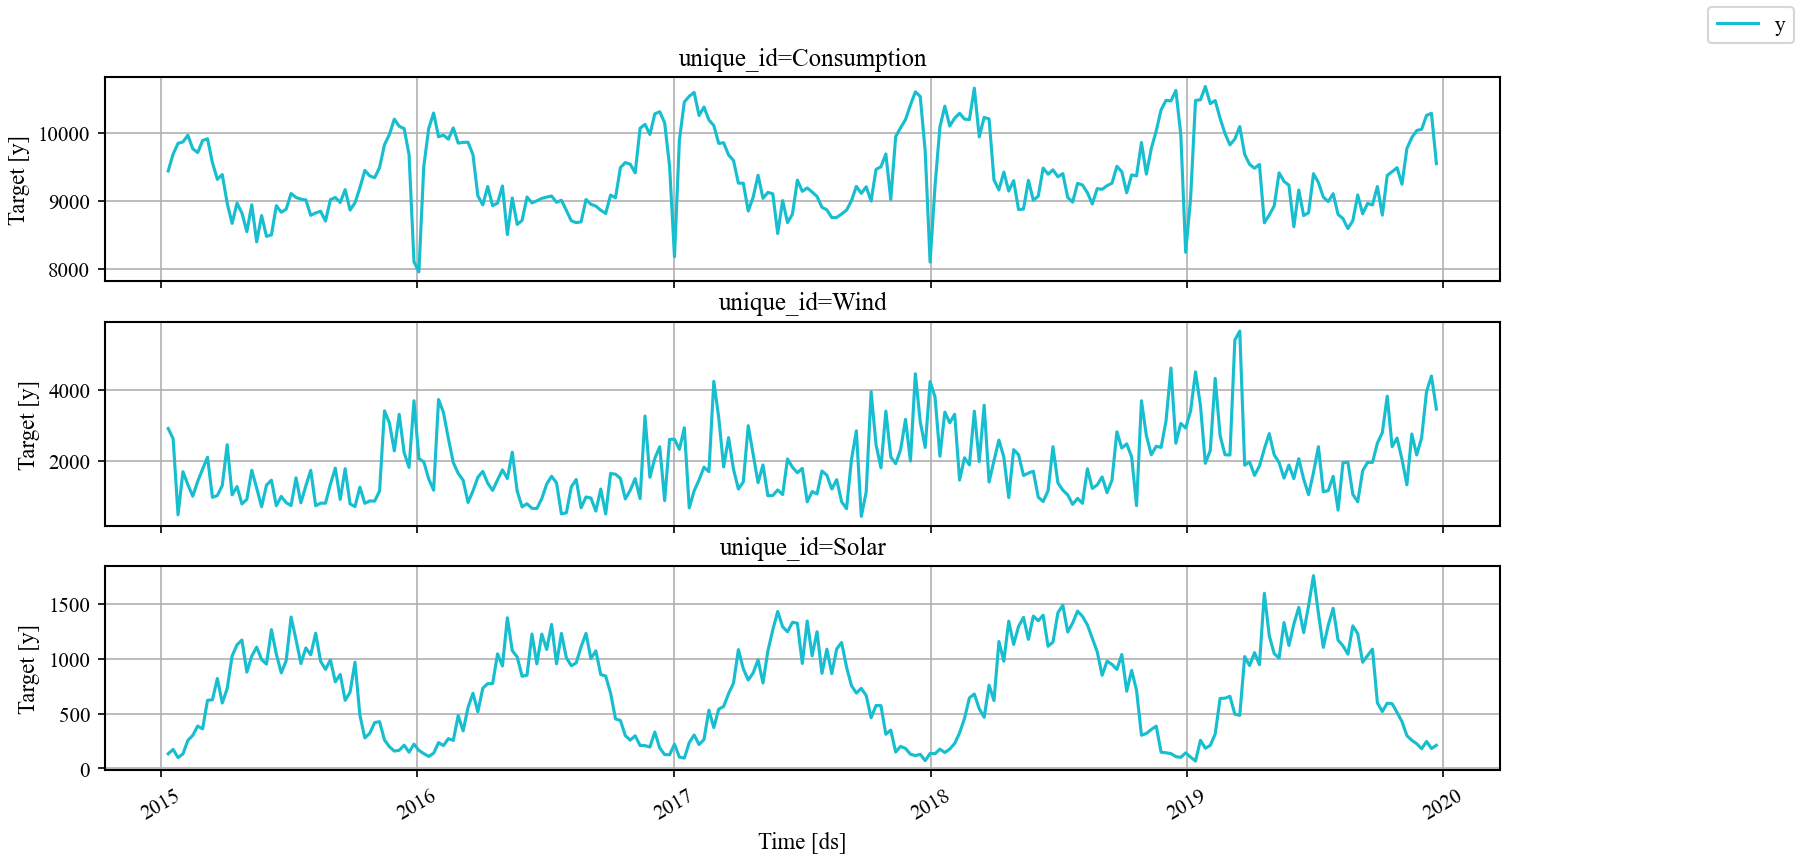

In [17]:
n_rows = len(panel_df['unique_id'].unique())
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)
plot_series(panel_df, ax = ax)

#### Мы будем использовать иногда функцию plot_series_v2

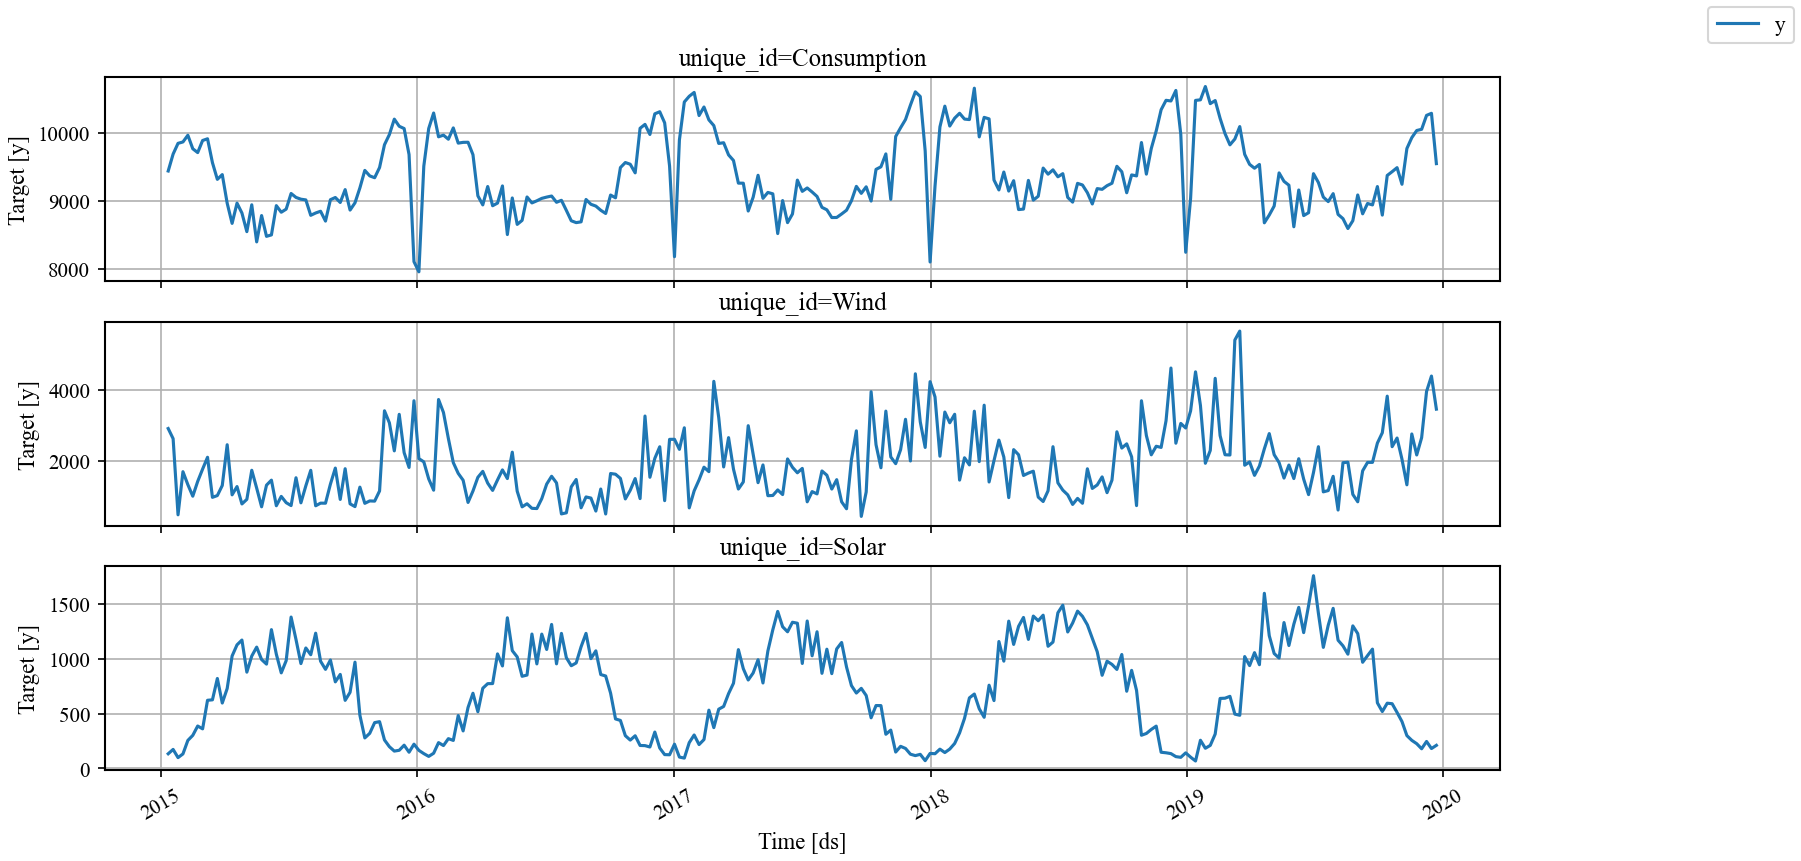

In [18]:
plot_series_v2(panel_df)

### Train Test Split

Разделим ВР на тренировочную и тестовую части. К сожалению на сегодня это возможно только в ручном режиме

In [19]:
FH = int(0.42 * y.shape[0])

In [20]:
df_test  = panel_df[base_cols].groupby("unique_id").tail(FH)
df_train = panel_df[base_cols].drop(df_test.index).reset_index(drop=True)

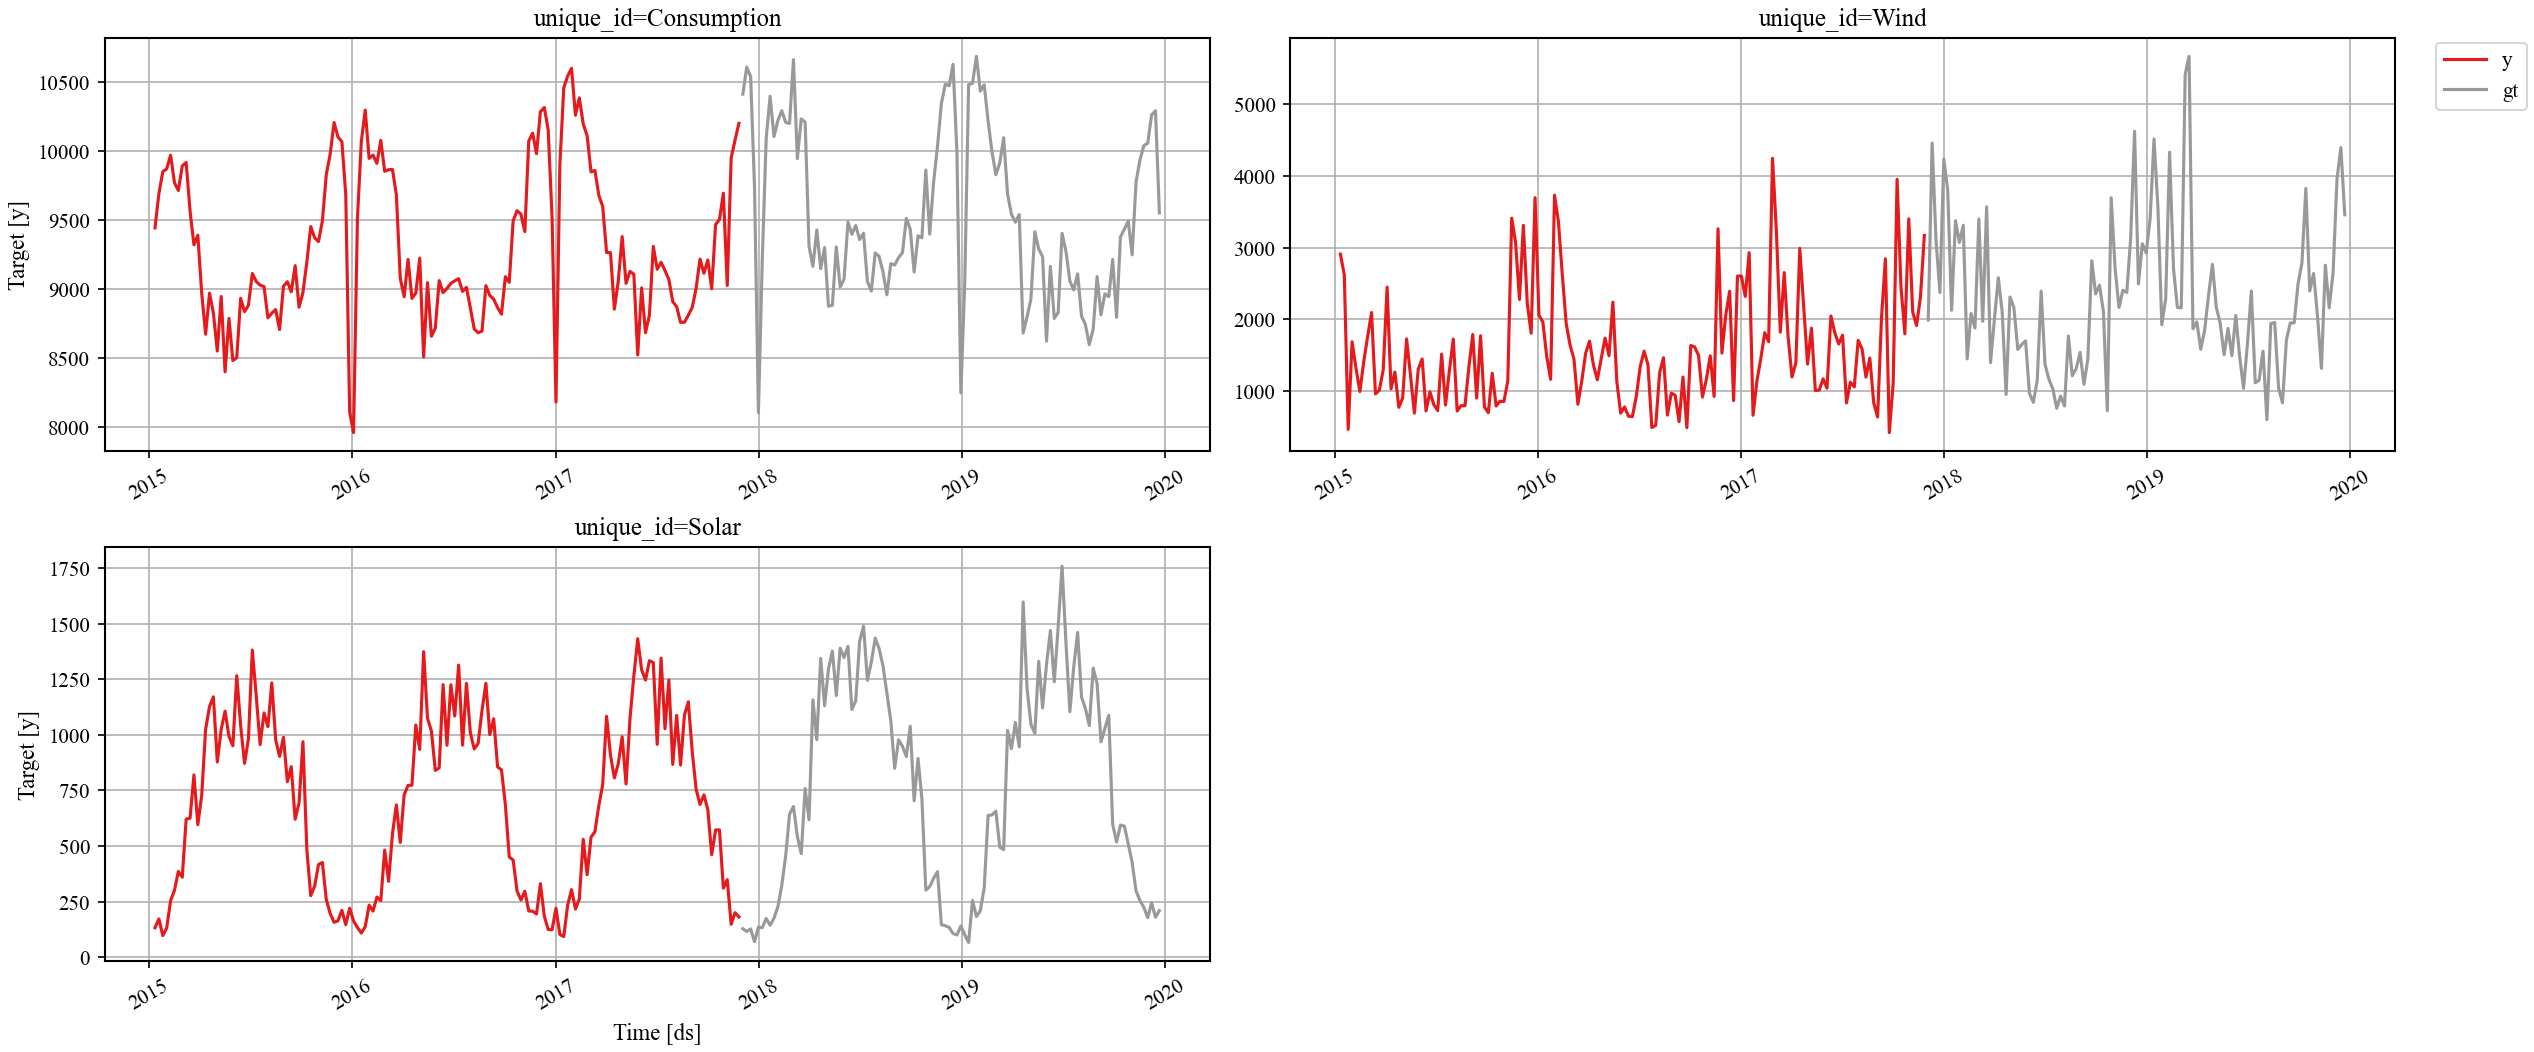

In [21]:
plot_series(df_train, df_test.rename(columns={"y": "gt"}),  palette='Set1')

## Дополнительно

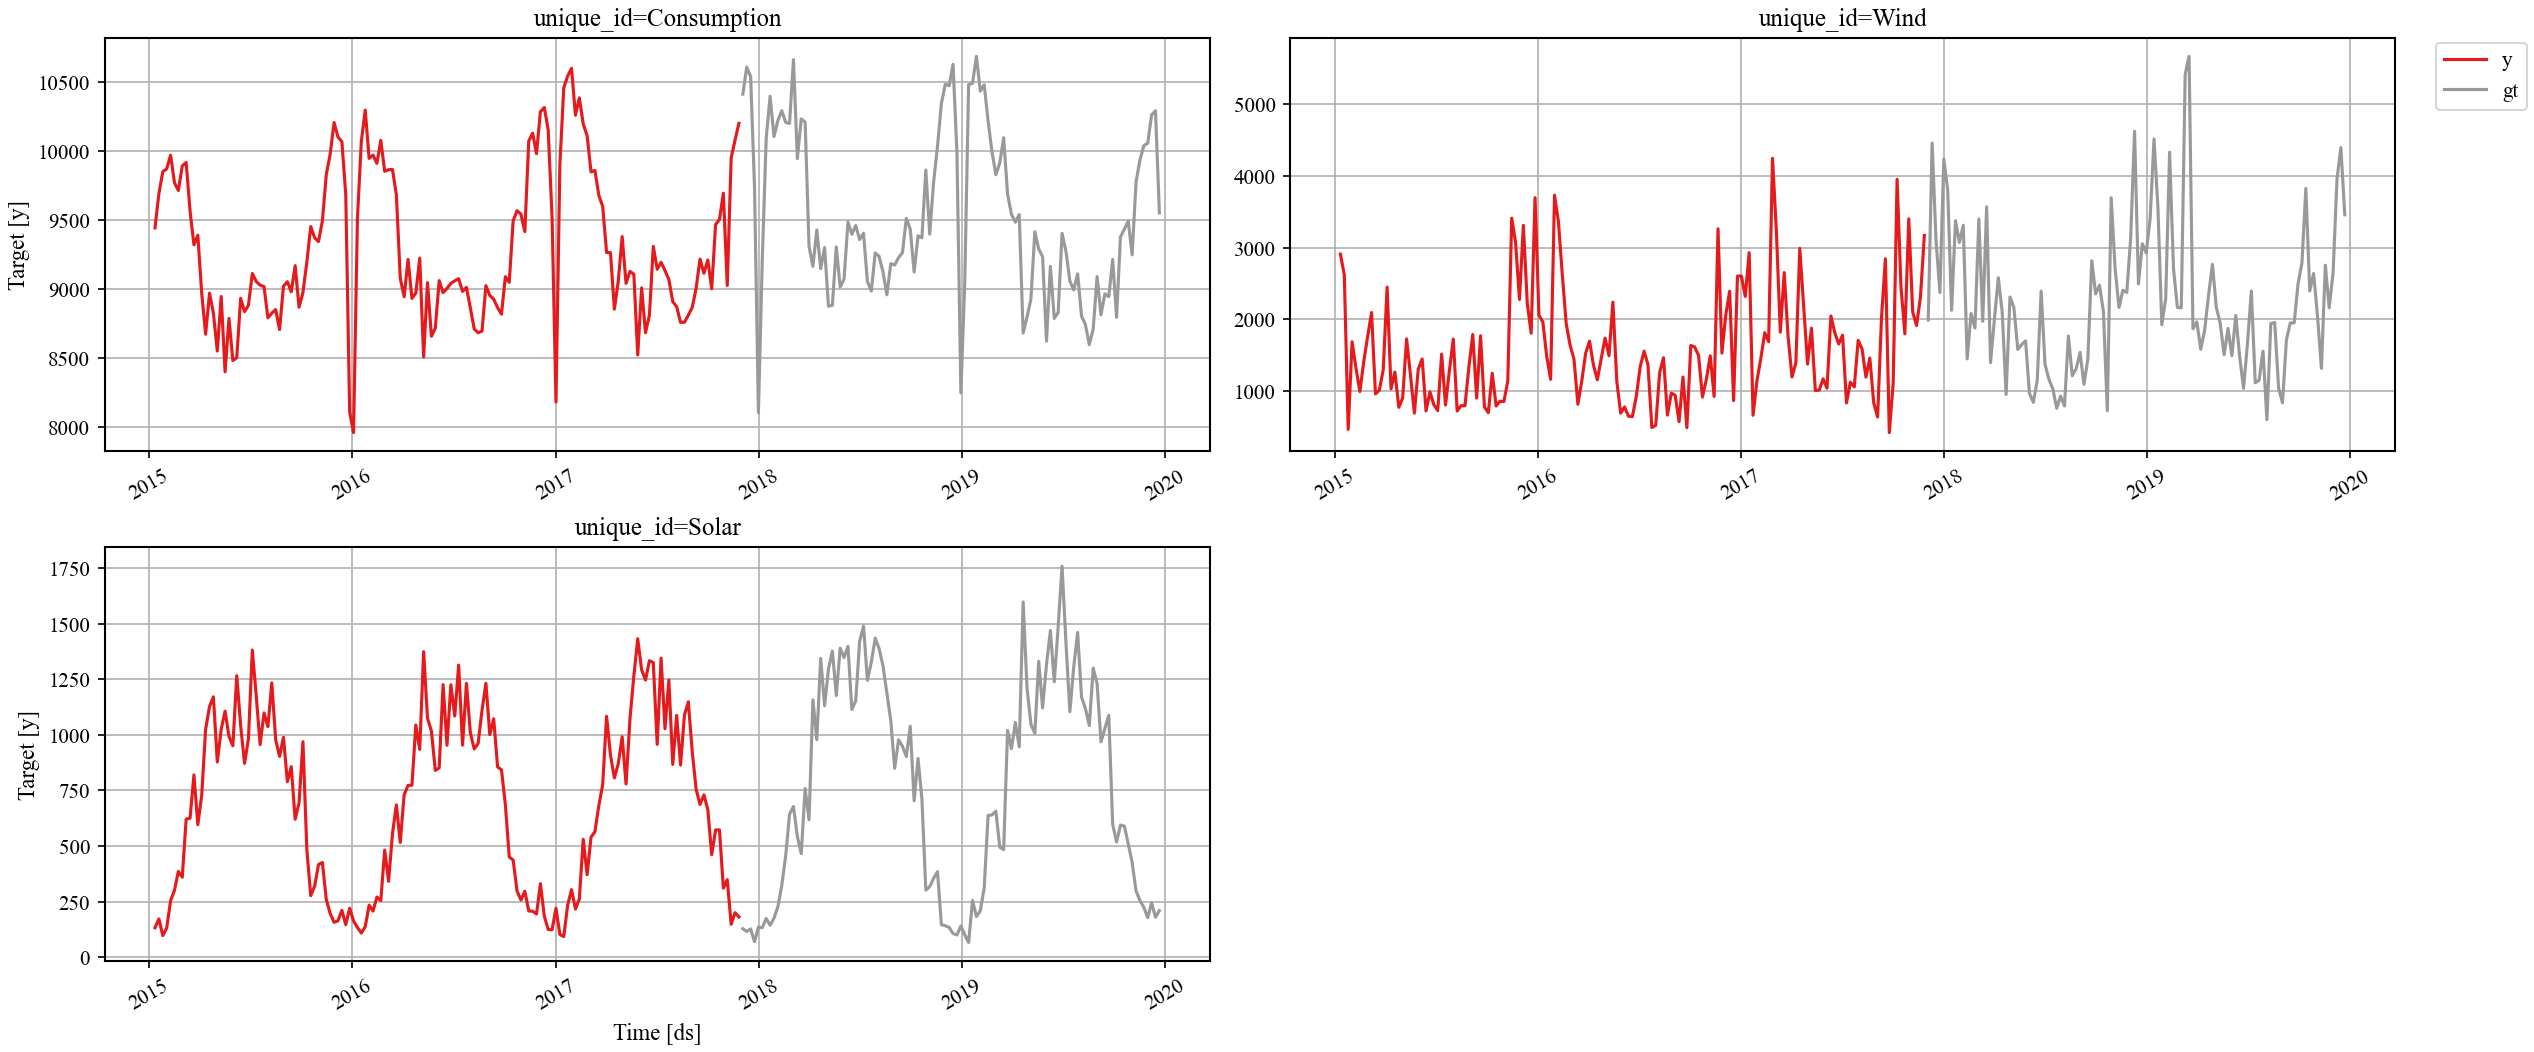

In [22]:
df= pd.read_csv(
    "OPDS_DE_EDA.csv",
    parse_dates=["time"],
    index_col="time"
)

df.head(1)
ts = ['Consumption','Wind',	'Solar']

exog_cols = ['temperature','radiation_direct_horizontal']

y = df.resample('W').agg({
    'Consumption': 'sum',
    'Wind': 'sum',
    'Solar': 'sum',
    'temperature': 'mean',
    'radiation_direct_horizontal': 'mean'
}).ffill().bfill() + 1e-8

y = y.iloc[1:-2]

ts = ['Consumption', 'Wind', 'Solar']
base_cols = ['unique_id', 'ds', 'y']

date_index = y.index
panel_list = [pd.DataFrame({'ds':date_index , 'y': y[t].values, 'unique_id': t}) for t in ts]
panel_df = pd.concat(panel_list, ignore_index=True)
panel_df = panel_df[base_cols] #порядок колонок
panel_df.sample(5)

FREQ = y.index.freq

SEASON = 52

FH = int(0.42 * y.shape[0])

df_test  = panel_df[base_cols].groupby("unique_id").tail(FH)
df_train = panel_df[base_cols].drop(df_test.index).reset_index(drop=True)

plot_series(df_train, df_test.rename(columns={"y": "gt"}),  palette='Set1')

In [28]:
import numpy as np
import pandas as pd
from typing import Optional, List, Dict
from statsforecast.models import _TS
from statsforecast.adapters.prophet import AutoARIMAProphet
from prophet.make_holidays import make_holidays_df


In [23]:
from prophet_adapter import TSProphet
from statsforecast.models import AutoARIMA

In [219]:

from statsforecast.arima import (
    Arima,
    auto_arima_f,
    fitted_arima,
    forecast_arima,
    forward_arima,
    is_constant,
)

from statsforecast.models import (_add_fitted_pi)

from prophet import Prophet as FBProphet
from prophet.make_holidays import make_holidays_df

In [220]:


class ARIMAProphet(_TS):
    r"""ARIMAProphet model.

    AutoRegressive Integrated Moving Average model.

    References:
        - [Rob J. Hyndman, Yeasmin Khandakar (2008). "Automatic Time Series Forecasting: The forecast package for R"](https://www.jstatsoft.org/article/view/v027i03).

    Args:
        order (tuple, default=(0, 0, 0)): A specification of the non-seasonal part of the ARIMA model: the three components (p, d, q) are the AR order, the degree of differencing, and the MA order.
        season_length (int, default=1): Number of observations per unit of time. Ex: 24 Hourly data.
        seasonal_order (tuple, default=(0, 0, 0)): A specification of the seasonal part of the ARIMA model. (P, D, Q) for the  AR order, the degree of differencing, the MA order.
        include_mean (bool, default=True): Should the ARIMA model include a mean term? The default is True for undifferenced series, False for differenced ones (where a mean would not affect the fit nor predictions).
        include_drift (bool, default=False): Should the ARIMA model include a linear drift term? (i.e., a linear regression with ARIMA errors is fitted.)
        include_constant (bool, optional, default=None): If True, then includ_mean is set to be True for undifferenced series and include_drift is set to be True for differenced series. Note that if there is more than one difference taken, no constant is included regardless of the value of this argument. This is deliberate as otherwise quadratic and higher order polynomial trends would be induced.
        blambda (float, optional, default=None): Box-Cox transformation parameter.
        biasadj (bool, default=False): Use adjusted back-transformed mean Box-Cox.
        method (str, default='CSS-ML'): Fitting method: maximum likelihood or minimize conditional sum-of-squares. The default (unless there are missing values) is to use conditional-sum-of-squares to find starting values, then maximum likelihood.
        fixed (dict, optional, default=None): Dictionary containing fixed coefficients for the arima model. Example: `{'ar1': 0.5, 'ma2': 0.75}`. For autoregressive terms use the `ar{i}` keys. For its seasonal version use `sar{i}`. For moving average terms use the `ma{i}` keys. For its seasonal version use `sma{i}`. For intercept and drift use the `intercept` and `drift` keys. For exogenous variables use the `ex_{i}` keys.
        alias (str): Custom name of the model.
        prediction_intervals (Optional[ConformalIntervals]): Information to compute conformal prediction intervals. By default, the model will compute the native prediction intervals.
    """

    uses_exog = True

    def __init__(
        self,
        order: Tuple[int, int, int] = (0, 0, 0),
        season_length: int = 1,
        seasonal_order: Tuple[int, int, int] = (0, 0, 0),
        include_mean: bool = True,
        include_drift: bool = False,
        include_constant: Optional[bool] = None,
        blambda: Optional[float] = None,
        biasadj: bool = False,
        method: str = "CSS-ML",
        fixed: Optional[dict] = None,
        alias: str = "ARIMAProphet",
        prediction_intervals: Optional[ConformalIntervals] = None,
        prophet: Optional[Any] = None,   # ← сюда передаем Prophet объект
        # #Prophet
        freq: str = "H",
        growth: str = "linear",
        yearly_seasonality: bool | int = False,
        weekly_seasonality: bool | int = False,
        daily_seasonality: bool | int = False,
        custom_seasonalities: Optional[List[Dict]] = None,
        seasonality_mode: str = "additive",
        seasonality_prior_scale: float = 10.0,
        holidays: Optional[pd.DataFrame] = None,
        country_holidays: Optional[str] = None,

    ):
        self.order = order
        self.season_length = season_length
        self.seasonal_order = seasonal_order
        self.include_mean = include_mean
        self.include_drift = include_drift
        self.include_constant = include_constant
        self.blambda = blambda
        self.biasadj = biasadj
        self.method = method
        self.fixed = fixed
        self.alias = alias
        self.prediction_intervals = prediction_intervals
        self.prophet = prophet,
        #Prophet
        self.freq = freq
        self.growth = growth
        self.yearly_seasonality = yearly_seasonality
        self.weekly_seasonality = weekly_seasonality
        self.daily_seasonality = daily_seasonality
        self.custom_seasonalities = custom_seasonalities or []
        self.seasonality_mode = seasonality_mode
        self.seasonality_prior_scale = seasonality_prior_scale
        self.holidays = holidays
        self.country_holidays = country_holidays

    def _merge_holidays(self, years):
        dfs = []
        if self.country_holidays:
            dfs.append(make_holidays_df(year_list=years, country=self.country_holidays))
        if self.holidays is not None:
            dfs.append(self.holidays.copy())
        if not dfs:
            return None
        return pd.concat(dfs, ignore_index=True)

    # -----------------------------
    def _add_custom_seasonalities(self, model: FBProphet):
        for s in self.custom_seasonalities:
            model.add_seasonality(
                name=s["name"],
                period=s["period"],
                fourier_order=s.get("fourier_order", 5),
            )

    # -----------------------------
    def _create_model(self, years=None):
        """Создаёт объект Prophet с учётом всех параметров"""
        holidays_df = self._merge_holidays(years)
        model = FBProphet(
            growth=self.growth,
            yearly_seasonality=self.yearly_seasonality,
            weekly_seasonality=self.weekly_seasonality,
            daily_seasonality=self.daily_seasonality,
            seasonality_mode=self.seasonality_mode,
            seasonality_prior_scale=self.seasonality_prior_scale,
            # interval_width=self.interval_width,
            holidays=holidays_df,
            # **self.kwargs,
        )
        self._add_custom_seasonalities(model)
        return model

   
    
    def fit(
        self,
        y: np.ndarray,
        X: Optional[np.ndarray] = None,
    ):
        r"""
        Fit the model to a time series (numpy array) `y`
        and optionally exogenous variables (numpy array) `X`.

        Args:
            y (numpy.array): Clean time series of shape (t, ).
            X (array-like): Optional exogenous of shape (t, n_x).

        Returns:
            self: Fitted model.
        """
        # y = _ensure_float(y)
        with np.errstate(invalid="ignore"):

            X_full = self._create_exog_train(y, X)
            
            self.model_ = Arima(
                x=y,
                order=self.order,
                seasonal={"order": self.seasonal_order, "period": self.season_length},
                xreg=X_full,
                include_mean=self.include_mean,
                include_constant=self.include_constant,
                include_drift=self.include_drift,
                blambda=self.blambda,
                biasadj=self.biasadj,
                method=self.method,
                fixed=self.fixed,
            )

        
        self._store_cs(y=y, X=X)
        return self
     
        
    def predict(
        self,
        h: int,
        X: Optional[np.ndarray] = None,
        level: Optional[List[int]] = None,
    ):
        r"""Predict with fitted model.

        Args:
            h (int): Forecast horizon.
            X (array-like): Optional exogenous of shape (h, n_x).
            level (List[float]): Confidence levels (0-100) for prediction intervals.

        Returns:
            forecasts (dict): Dictionary with entries `mean` for point predictions and `level_*` for probabilistic predictions.
        """

        X_full = self._create_exog_future(y, X, h=h)
        
        fcst = forecast_arima(self.model_, h=h, xreg=X_full, level=level)
        mean = fcst["mean"]
        res = {"mean": mean}
        if level is None:
            return res
        level = sorted(level)
        if self.prediction_intervals is not None:
            res = self._add_predict_conformal_intervals(res, level)
        else:
            res = {
                "mean": mean,
                **{f"lo-{l}": fcst["lower"][f"{l}%"] for l in reversed(level)},
                **{f"hi-{l}": fcst["upper"][f"{l}%"] for l in level},
            }
        return res

    def predict_in_sample(self, level: Optional[List[int]] = None):
        r"""Access fitted insample predictions.

        Args:
            level (List[float]): Confidence levels (0-100) for prediction intervals.

        Returns:
            forecasts (dict): Dictionary with entries `fitted` for point predictions and `level_*` for probabilistic predictions.
        """
        mean = fitted_arima(self.model_)
        res = {"fitted": mean}
        if level is not None:
            se = np.sqrt(self.model_["sigma2"])
            res = _add_fitted_pi(res=res, se=se, level=level)
        return res

    def forecast(
        self,
        y: np.ndarray,
        h: int,
        X: Optional[np.ndarray] = None,
        X_future: Optional[np.ndarray] = None,
        level: Optional[List[int]] = None,
        fitted: bool = False,
    ):
        r"""Memory efficient predictions.

        This method avoids memory burden due from object storage.
        It is analogous to `fit_predict` without storing information.
        It assumes you know the forecast horizon in advance.

        Args:
            y (numpy.array): Clean time series of shape (n, ).
            h (int): Forecast horizon.
            X (array-like): Optional insample exogenous of shape (t, n_x).
            X_future (array-like): Optional exogenous of shape (h, n_x) optional exogenous.
            level (List[float]): Confidence levels (0-100) for prediction intervals.
            fitted (bool): Whether or not returns insample predictions.

        Returns:
            forecasts (dict): Dictionary with entries `mean` for point predictions and `level_*` for probabilistic predictions.
        """
        # y = _ensure_float(y)
        X_train = self._create_exog_train(y, X)
        X_fut   = self._create_exog_future(y, X_future, h=h)
        
        with np.errstate(invalid="ignore"):

            mod = Arima(
                x=y,
                order=self.order,
                seasonal={"order": self.seasonal_order, "period": self.season_length},
                xreg=X_train,
                include_mean=self.include_mean,
                include_constant=self.include_constant,
                include_drift=self.include_drift,
                blambda=self.blambda,
                biasadj=self.biasadj,
                method=self.method,
                fixed=self.fixed,
            )
            
        fcst = forecast_arima(mod, h, xreg=X_fut, level=level)
        res = {"mean": fcst["mean"]}
        if fitted:
            res["fitted"] = fitted_arima(mod)
        if level is not None:
            level = sorted(level)
            if self.prediction_intervals is not None:
                res = self._add_conformal_intervals(fcst=res, y=y, X=X, level=level)
            else:
                res = {
                    **res,
                    **{f"lo-{l}": fcst["lower"][f"{l}%"] for l in reversed(level)},
                    **{f"hi-{l}": fcst["upper"][f"{l}%"] for l in level},
                }
            if fitted:
                # add prediction intervals for fitted values
                se = np.sqrt(mod["sigma2"])
                res = _add_fitted_pi(res=res, se=se, level=level)
        return res

    def forward(
        self,
        y: np.ndarray,
        h: int,
        X: Optional[np.ndarray] = None,
        X_future: Optional[np.ndarray] = None,
        level: Optional[List[int]] = None,
        fitted: bool = False,
    ):
        r"""Apply fitted model to a new time series.

        Args:
            y (numpy.array): Clean time series of shape (n, ).
            h (int): Forecast horizon.
            X (array-like): Optional insample exogenous of shape (t, n_x).
            X_future (array-like): Optional exogenous of shape (h, n_x).
            level (List[float]): Confidence levels for prediction intervals.
            fitted (bool): Whether or not returns insample predictions.

        Returns:
            forecasts (dict): Dictionary with entries `mean` for point predictions and `level_*` for probabilistic predictions.
        """
        if not hasattr(self, "model_"):
            raise Exception("You have to use the `fit` method first")
        # y = _ensure_float(y)
        
        X_train = self._create_exog_train(y, X)
        X_fut   = self._create_exog_future(y, X_future, h=h)
        
        with np.errstate(invalid="ignore"):
            mod = forward_arima(self.model_, y=y, xreg=X_train, method=self.method)
        fcst = forecast_arima(mod, h, xreg=X_fut, level=level)
        res = {"mean": fcst["mean"]}
        if fitted:
            res["fitted"] = fitted_arima(mod)
        if level is not None:
            level = sorted(level)
            if self.prediction_intervals is not None:
                res = self._add_conformal_intervals(fcst=res, y=y, X=X_train, level=level)
            else:
                res = {
                    **res,
                    **{f"lo-{l}": fcst["lower"][f"{l}%"] for l in reversed(level)},
                    **{f"hi-{l}": fcst["upper"][f"{l}%"] for l in level},
                }
            if fitted:
                # add prediction intervals for fitted values
                se = np.sqrt(mod["sigma2"])
                res = _add_fitted_pi(res=res, se=se, level=level)
        return res


    def _create_exog_train(self, y: np.ndarray, X: Optional[np.ndarray] = None) -> Optional[np.ndarray]:
        """Экзогены только для обучающего ряда"""
        import pandas as pd
        import numpy as np
        from prophet import Prophet
    
        ds_train = pd.date_range("1970-01-01", periods=len(y), freq=self.freq)
        df_train = pd.DataFrame({"ds": ds_train, "y": y})
    
        prophet = self._create_model()
        prophet.fit(df_train)
        seasonal_train, _, component_cols, _ = prophet.make_all_seasonality_features(df_train)
        self.xreg_cols = component_cols
        X_seasonal = seasonal_train.values if not seasonal_train.empty else None
    
        if X is not None:
            X_full = np.hstack([X_seasonal, X]) if X_seasonal is not None else X
        else:
            X_full = X_seasonal
    
        return X_full
    
    
    def _create_exog_future(self, y: np.ndarray, X_future: Optional[np.ndarray] = None, h: int = 0) -> Optional[np.ndarray]:
        """Экзогены только для будущих шагов"""
        import pandas as pd
        import numpy as np
        from prophet import Prophet
    
        ds_train = pd.date_range("1970-01-01", periods=len(y), freq=self.freq)
        ds_future = pd.date_range(
            start=ds_train[-1] + pd.tseries.frequencies.to_offset(self.freq),
            periods=h,
            freq=self.freq
        )
        df_future = pd.DataFrame({"ds": ds_future, "y": np.zeros(h)})
    
        prophet = self._create_model()
        prophet.fit(pd.DataFrame({"ds": ds_train, "y": y}))  # Prophet должен знать тренд
    
        seasonal_future, _, _, _ = prophet.make_all_seasonality_features(df_future)
        X_seasonal_future = seasonal_future.values if not seasonal_future.empty else None
    
        if X_future is not None:
            X_full_future = np.hstack([X_seasonal_future, X_future]) if X_seasonal_future is not None else X_future
        else:
            X_full_future = X_seasonal_future
    
        return X_full_future





In [221]:
from statsforecast import StatsForecast
LEVELS = [70,90]

models = [ARIMAProphet( order=(3, 1, 1),
    seasonal_order=(1, 1, 0),
    season_length=SEASON,
    freq = FREQ,
    yearly_seasonality = 12, 
    country_holidays = 'GE',               
 alias='test_1' ),
         ]

sf = StatsForecast(models=models, freq=FREQ, n_jobs=1)
# sf.fit(df=df_train, )
fcst_sf = sf.forecast(df=df_train, h=FH,)

# in_sample = sf.forecast_fitted_values()

eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

15:37:17 - cmdstanpy - INFO - Chain [1] start processing
15:37:17 - cmdstanpy - INFO - Chain [1] done processing
15:37:17 - cmdstanpy - INFO - Chain [1] start processing
15:37:17 - cmdstanpy - INFO - Chain [1] done processing
15:37:20 - cmdstanpy - INFO - Chain [1] start processing
15:37:20 - cmdstanpy - INFO - Chain [1] done processing
15:37:20 - cmdstanpy - INFO - Chain [1] start processing
15:37:20 - cmdstanpy - INFO - Chain [1] done processing
15:37:23 - cmdstanpy - INFO - Chain [1] start processing
15:37:23 - cmdstanpy - INFO - Chain [1] done processing
15:37:23 - cmdstanpy - INFO - Chain [1] start processing
15:37:23 - cmdstanpy - INFO - Chain [1] done processing


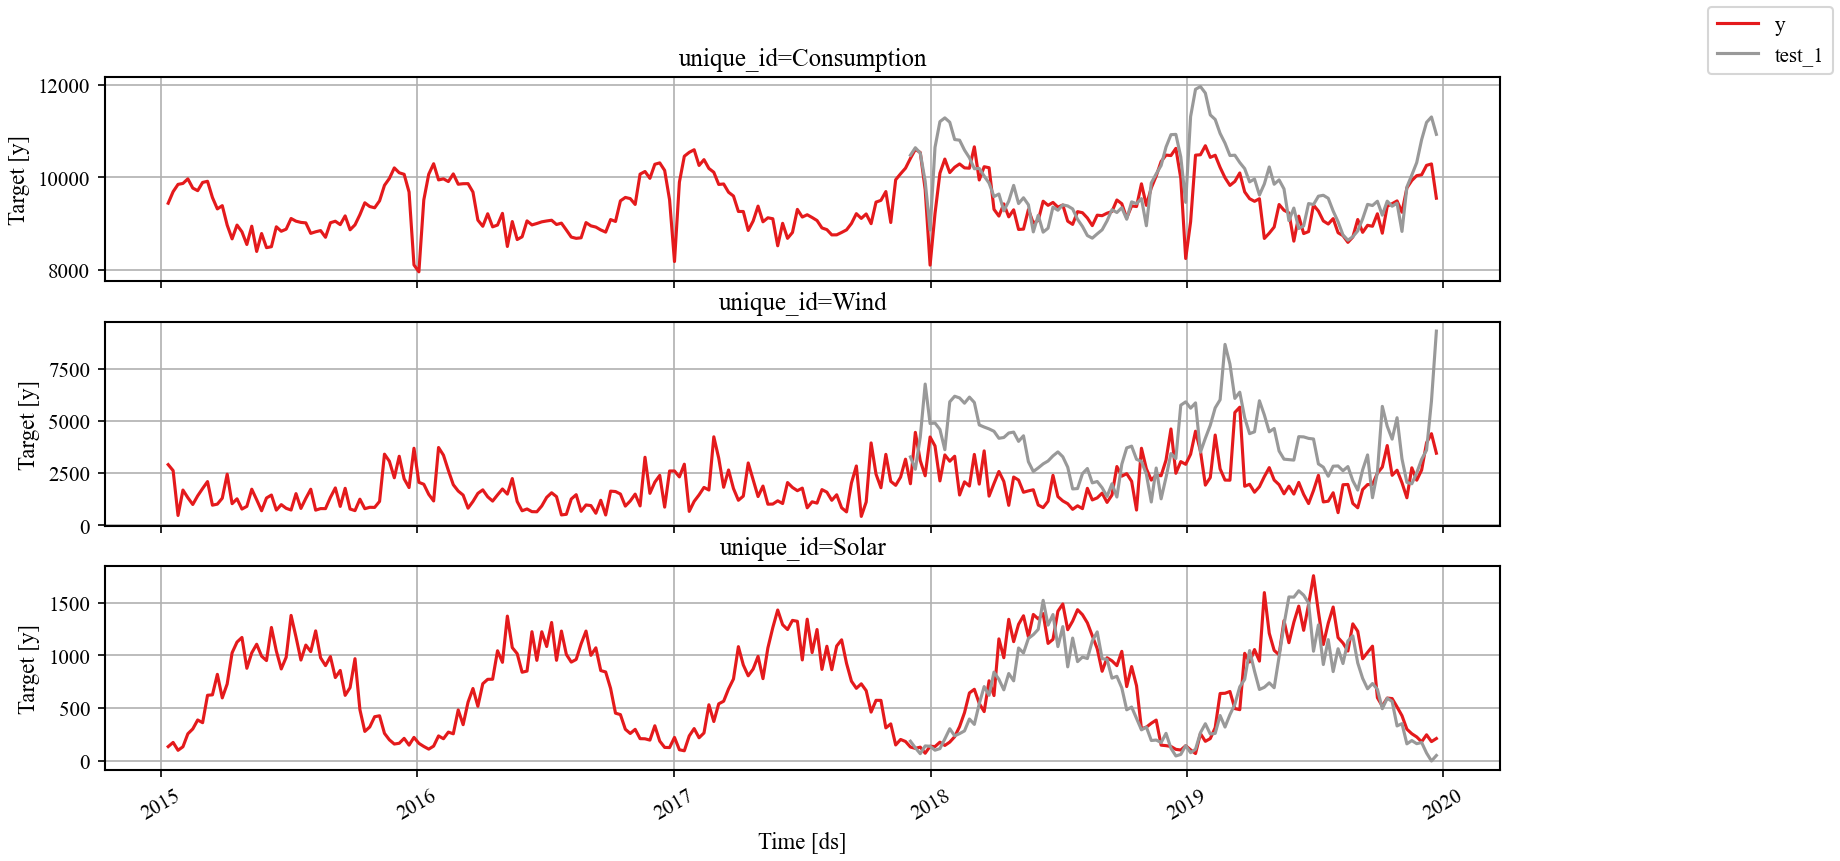

In [222]:
evaluate_and_plot(df_train, df_test, eval_sf, metrics = [mae, rmse, ], )

In [223]:
from statsforecast import StatsForecast
LEVELS = [70,90]

sf = StatsForecast(models=models, freq=FREQ, n_jobs=1)

fcst_sf = sf.forecast(df=df_train, h=FH, level = LEVELS, fitted=True)

in_sample = sf.forecast_fitted_values()

eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

15:37:26 - cmdstanpy - INFO - Chain [1] start processing
15:37:26 - cmdstanpy - INFO - Chain [1] done processing
15:37:26 - cmdstanpy - INFO - Chain [1] start processing
15:37:26 - cmdstanpy - INFO - Chain [1] done processing
15:37:29 - cmdstanpy - INFO - Chain [1] start processing
15:37:29 - cmdstanpy - INFO - Chain [1] done processing
15:37:29 - cmdstanpy - INFO - Chain [1] start processing
15:37:29 - cmdstanpy - INFO - Chain [1] done processing
15:37:32 - cmdstanpy - INFO - Chain [1] start processing
15:37:32 - cmdstanpy - INFO - Chain [1] done processing
15:37:32 - cmdstanpy - INFO - Chain [1] start processing
15:37:32 - cmdstanpy - INFO - Chain [1] done processing


In [224]:
in_sample

,unique_id,ds,y,test_1,test_1-lo-90,test_1-lo-70,test_1-hi-70,test_1-hi-90
0,Consumption,2015-01-11,9440.105,9439.226184,8934.462966,9121.171468,9757.280900,9943.989403
1,Consumption,2015-01-18,9689.010,9686.391469,9181.628251,9368.336753,10004.446185,10191.154687
2,Consumption,2015-01-25,9847.035,9843.081377,9338.318158,9525.026660,10161.136093,10347.844595
3,Consumption,2015-02-01,9867.317,9862.473144,9357.709925,9544.418428,10180.527860,10367.236362
4,Consumption,2015-02-08,9966.415,9960.983742,9456.220523,9642.929025,10279.038458,10465.746960
...,...,...,...,...,...,...,...,...
448,Wind,2017-10-29,3400.181,2286.061329,1228.550803,1619.716798,2952.405861,3343.571856
449,Wind,2017-11-05,2105.870,2066.204044,1008.693517,1399.859513,2732.548576,3123.714571
450,Wind,2017-11-12,1914.513,2158.379566,1100.869039,1492.035034,2824.724097,3215.890092
451,Wind,2017-11-19,2309.436,2433.385996,1375.875470,1767.041465,3099.730528,3490.896523


In [225]:
fcst_sf

,unique_id,ds,test_1,test_1-lo-90,test_1-lo-70,test_1-hi-70,test_1-hi-90
0,Consumption,2017-12-03,10477.821164,9973.057945,10159.766448,10795.875880,10982.584382
1,Consumption,2017-12-10,10639.203753,10131.444617,10319.261289,10959.146217,11146.962889
2,Consumption,2017-12-17,10523.278498,10009.931475,10199.815069,10846.741927,11036.625521
3,Consumption,2017-12-24,9914.401816,9382.054378,9578.966096,10249.837535,10446.749253
4,Consumption,2017-12-31,8861.506992,8316.064525,8517.820006,9205.193978,9406.949459
...,...,...,...,...,...,...,...
319,Wind,2019-11-24,2514.687002,-725.902918,472.769387,4556.604617,5755.276922
320,Wind,2019-12-01,3162.933305,-319.164512,968.839932,5357.026679,6645.031123
321,Wind,2019-12-08,3603.382982,73.254732,1379.025308,5827.740656,7133.511233
322,Wind,2019-12-15,5958.783064,2425.711403,3732.570727,8184.995400,9491.854724


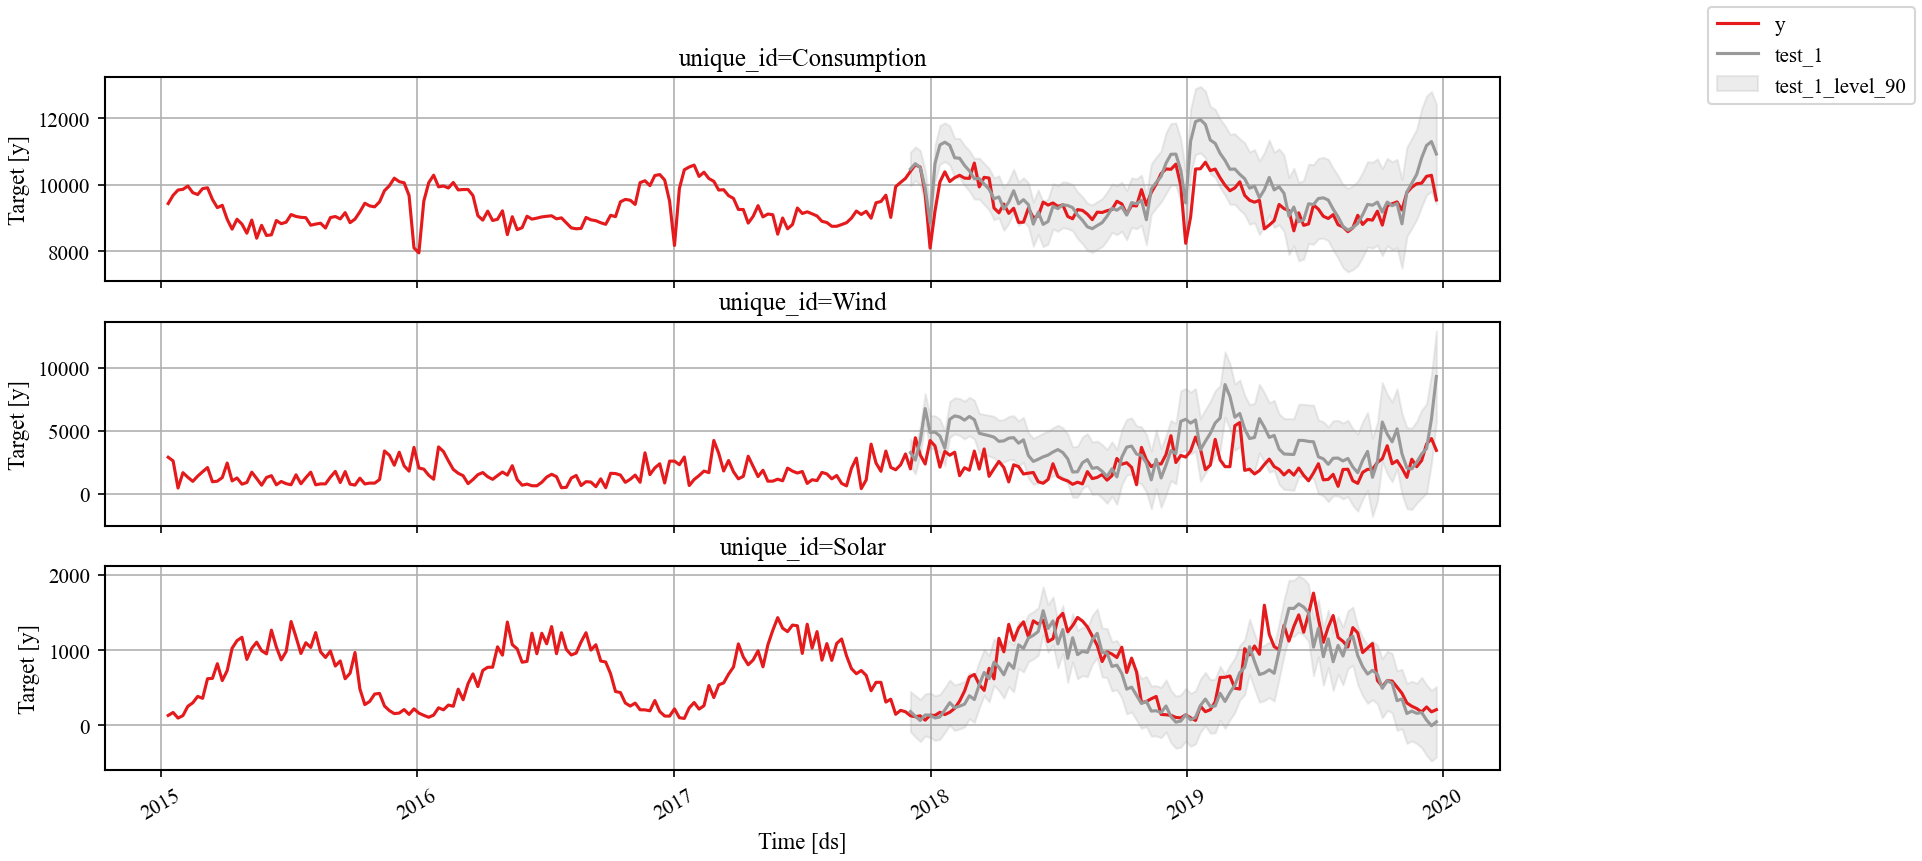

In [226]:

evaluate_and_plot(df_train, df_test, eval_sf, metrics = [mae, rmse, ], levels=LEVELS[1:])

In [229]:
cv_df = sf.cross_validation(
    df=panel_df,
    h=FH//4,
    n_windows=2,
    step_size=FH//8, 
    # refit=True,
)
cv_df.head()

15:38:11 - cmdstanpy - INFO - Chain [1] start processing
15:38:11 - cmdstanpy - INFO - Chain [1] done processing
15:38:11 - cmdstanpy - INFO - Chain [1] start processing
15:38:11 - cmdstanpy - INFO - Chain [1] done processing
15:38:12 - cmdstanpy - INFO - Chain [1] start processing
15:38:12 - cmdstanpy - INFO - Chain [1] done processing
15:38:12 - cmdstanpy - INFO - Chain [1] start processing
15:38:12 - cmdstanpy - INFO - Chain [1] done processing
15:38:16 - cmdstanpy - INFO - Chain [1] start processing
15:38:16 - cmdstanpy - INFO - Chain [1] done processing
15:38:16 - cmdstanpy - INFO - Chain [1] start processing
15:38:16 - cmdstanpy - INFO - Chain [1] done processing
15:38:19 - cmdstanpy - INFO - Chain [1] start processing
15:38:19 - cmdstanpy - INFO - Chain [1] done processing
15:38:19 - cmdstanpy - INFO - Chain [1] start processing
15:38:19 - cmdstanpy - INFO - Chain [1] done processing
15:38:23 - cmdstanpy - INFO - Chain [1] start processing
15:38:23 - cmdstanpy - INFO - Chain [1]

,unique_id,ds,cutoff,y,test_1
0,Consumption,2019-03-24,2019-03-17,9685.093,9996.689067
1,Consumption,2019-03-31,2019-03-17,9537.614,9337.018797
2,Consumption,2019-04-07,2019-03-17,9480.888,9248.180758
3,Consumption,2019-04-14,2019-03-17,9536.683,9219.141692
4,Consumption,2019-04-21,2019-03-17,8678.252,9055.387053


In [232]:
from statsforecast.utils import ConformalIntervals

# # Безопасный горизонт для конформной калибровки
# h = min(FH, df_train.groupby('unique_id').size().min() // 8)

# # Конформная калибровка (n_windows=2 обязательно)
# pi = ConformalIntervals(h=h, n_windows=2)

# forecasts = sf.forecast(
#     df=df_train,
#     h=h,
#     level=LEVELS,           # уровень PI
#     prediction_intervals=pi
# )

15:39:15 - cmdstanpy - INFO - Chain [1] start processing
15:39:15 - cmdstanpy - INFO - Chain [1] done processing
15:39:15 - cmdstanpy - INFO - Chain [1] start processing
15:39:15 - cmdstanpy - INFO - Chain [1] done processing
15:39:18 - cmdstanpy - INFO - Chain [1] start processing
15:39:18 - cmdstanpy - INFO - Chain [1] done processing
15:39:18 - cmdstanpy - INFO - Chain [1] start processing
15:39:18 - cmdstanpy - INFO - Chain [1] done processing


ValueError: Not enough data to fit the model

In [104]:
forecasts

,unique_id,ds,test_1,test_1-lo-70,test_1-hi-70,test_1-lo-90,test_1-hi-90,Prophet,Prophet-lo-70,Prophet-hi-70,Prophet-lo-90,Prophet-hi-90
0,Consumption,2017-12-03,10492.007309,10150.438452,10828.197231,10150.438452,10828.197231,10490.751009,10151.928652,10856.736988,10151.928652,10856.736988
1,Consumption,2017-12-10,10292.650702,9926.954331,10660.188289,9926.954331,10660.188289,10291.110062,9933.638536,10649.238715,9933.638536,10649.238715
2,Consumption,2017-12-17,9679.310599,9292.279465,10018.491534,9292.279465,10018.491534,9677.361776,9308.960257,10022.506824,9308.960257,10022.506824
3,Consumption,2017-12-24,9024.742835,8675.483852,9371.304319,8675.483852,9371.304319,9022.829199,8652.330528,9380.182304,8652.330528,9380.182304
4,Consumption,2017-12-31,8796.851975,8462.162646,9137.134190,8462.162646,9137.134190,8795.813768,8449.573722,9143.539656,8449.573722,9143.539656
...,...,...,...,...,...,...,...,...,...,...,...,...
145,Wind,2018-10-14,2178.283991,1101.202365,3271.067503,1101.202365,3271.067503,2175.645368,1138.835592,3160.370416,1138.835592,3160.370416
146,Wind,2018-10-21,2067.807445,973.823232,3179.910359,973.823232,3179.910359,2067.492634,1031.429398,3120.975600,1031.429398,3120.975600
147,Wind,2018-10-28,1850.804228,805.412570,2968.099893,805.412570,2968.099893,1853.042889,826.422871,2921.554366,826.422871,2921.554366
148,Wind,2018-11-04,1896.198400,759.705923,3019.188465,759.705923,3019.188465,1895.428338,820.941767,2929.659580,820.941767,2929.659580


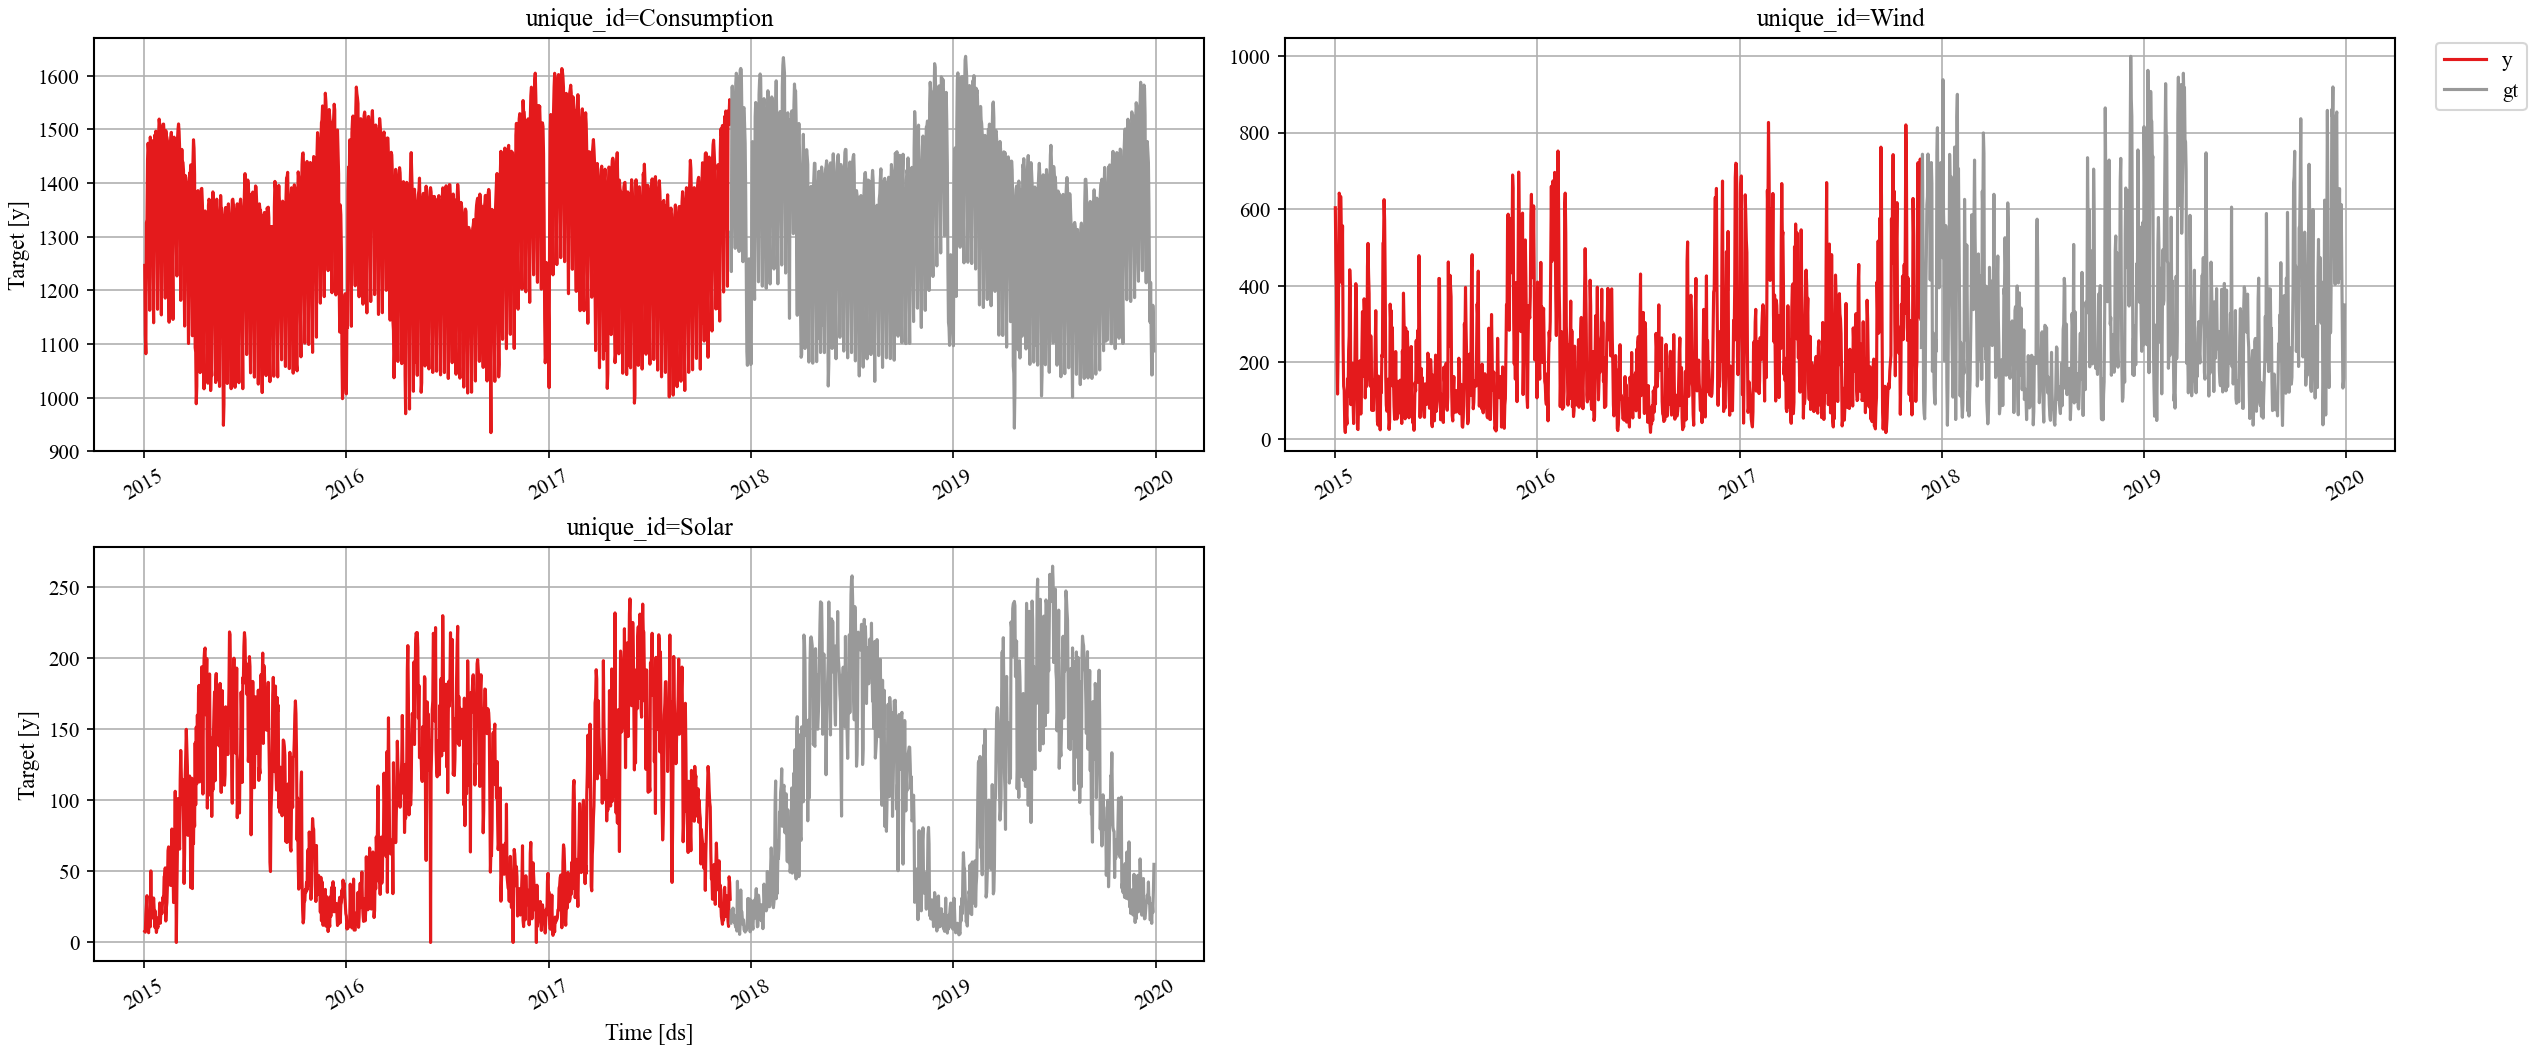

In [241]:
y = df_.resample('D').agg({
    'Consumption': 'sum',
    'Wind': 'sum',
    'Solar': 'sum',
    'temperature': 'mean',
    'radiation_direct_horizontal': 'mean'
}).ffill().bfill() + 1e-8

y = y.iloc[1:-2]



ts = ['Consumption', 'Wind', 'Solar']
base_cols = ['unique_id', 'ds', 'y']

date_index = y.index
panel_list = [pd.DataFrame({'ds':date_index , 'y': y[t].values, 'unique_id': t}) for t in ts]
panel_df = pd.concat(panel_list, ignore_index=True)
panel_df = panel_df[base_cols] #порядок колонок
panel_df.sample(5)

FREQ = y.index.freq

# SEASON = find_season_length(y['Consumption'].values, max_season_length = 55)
SEASON = [7,365] # 53 недели в году

FH = int(0.42 * y.shape[0])

df_test  = panel_df[base_cols].groupby("unique_id").tail(FH)
df_train = panel_df[base_cols].drop(df_test.index).reset_index(drop=True)

plot_series(df_train, df_test.rename(columns={"y": "gt"}),  palette='Set1')

In [242]:
SEASON

[7, 365]

In [256]:
custom_seasonalities = [
    {"name": "quartAL", "period": 90, "fourier_order": 3},
    # {"name": "half_day", "period": 12, "fourier_order": 5},
]
models = [ARIMAProphet( order=(3, 1, 1),
    seasonal_order=(1, 1, 1),
    season_length=SEASON[0],
    freq = FREQ,
    yearly_seasonality = 3, 
    weekly_seasonality=3,    
    seasonality_mode = "additive",
    seasonality_prior_scale = 10.0,                   
    # daily_seasonality=1, 
    custom_seasonalities=custom_seasonalities,
    # country_holidays = 'GE',               
     alias='test_1' ),
         ]



sf = StatsForecast(models=models, freq=FREQ, n_jobs=1)

fcst_sf = sf.forecast(df=df_train, h=FH, level = LEVELS, fitted=True)

in_sample = sf.forecast_fitted_values()

eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

19:09:45 - cmdstanpy - INFO - Chain [1] start processing
19:09:45 - cmdstanpy - INFO - Chain [1] done processing
19:09:45 - cmdstanpy - INFO - Chain [1] start processing
19:09:45 - cmdstanpy - INFO - Chain [1] done processing
19:09:47 - cmdstanpy - INFO - Chain [1] start processing
19:09:47 - cmdstanpy - INFO - Chain [1] done processing
19:09:47 - cmdstanpy - INFO - Chain [1] start processing
19:09:47 - cmdstanpy - INFO - Chain [1] done processing
19:09:49 - cmdstanpy - INFO - Chain [1] start processing
19:09:49 - cmdstanpy - INFO - Chain [1] done processing
19:09:49 - cmdstanpy - INFO - Chain [1] start processing
19:09:49 - cmdstanpy - INFO - Chain [1] done processing


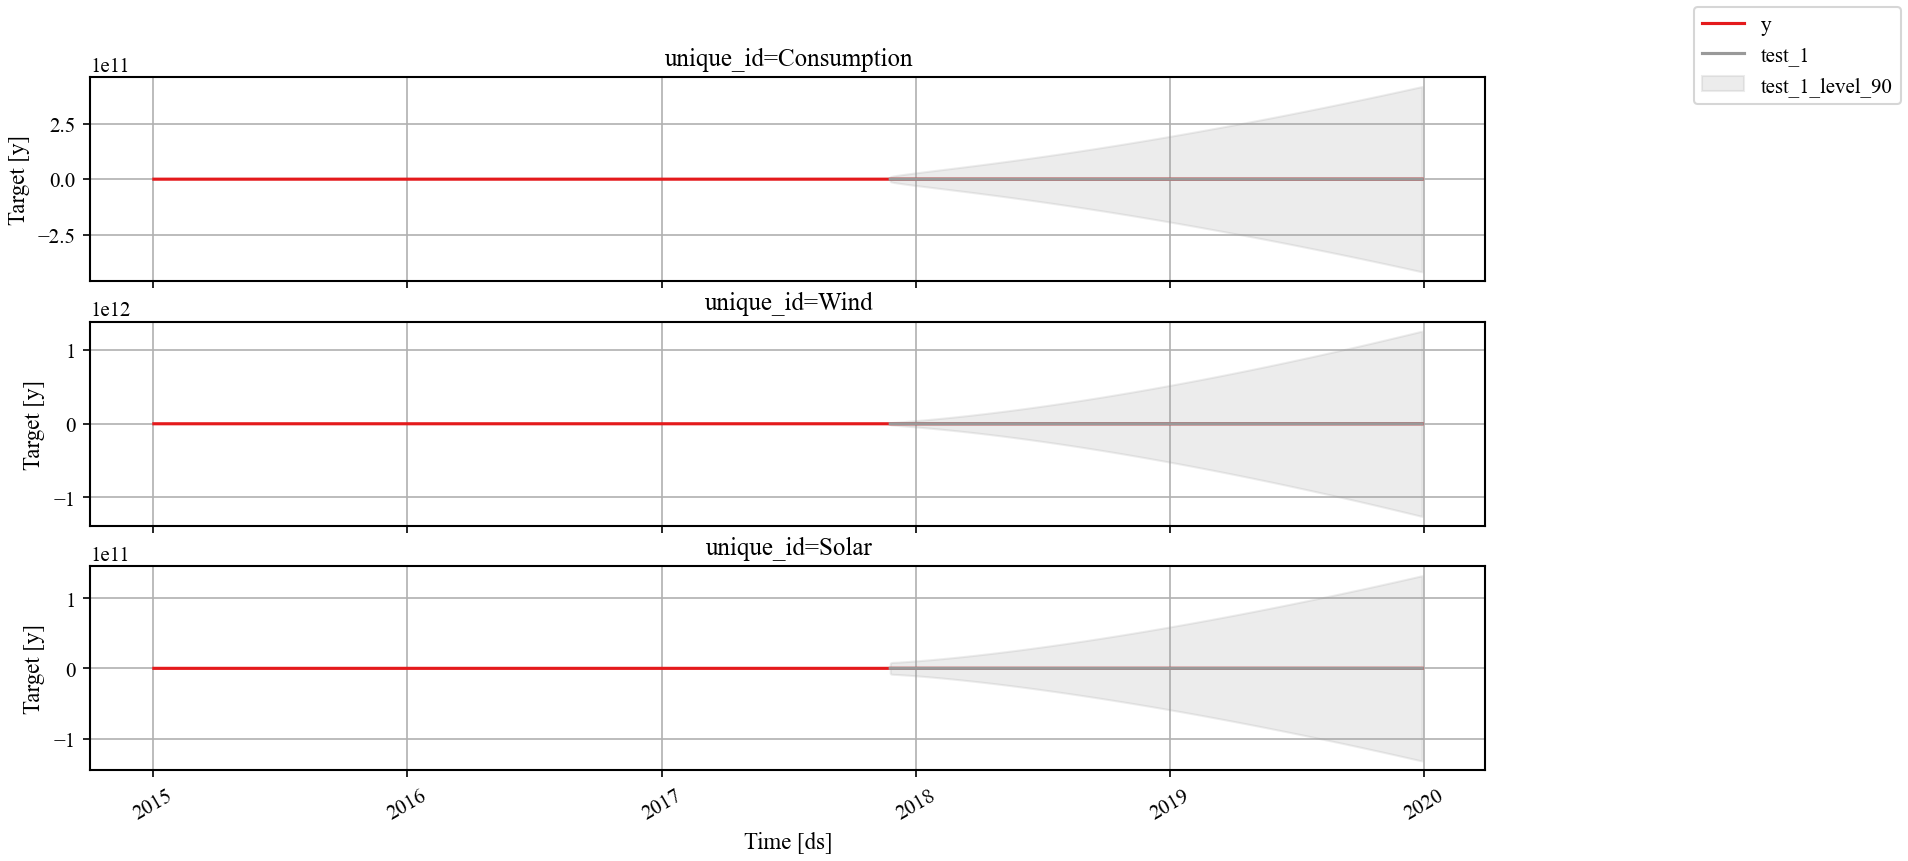

In [257]:

evaluate_and_plot(df_train, df_test, eval_sf, metrics = [mae, rmse, ], levels=LEVELS[1:])